<a href="https://colab.research.google.com/github/AmazingAadi29/Repository_AG/blob/main/mnist_digit_recognition_cnn_Gotpagar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#imports
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import callbacks
from tensorflow.keras import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import SGD
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
dr_data = keras.datasets.mnist.load_data(path="mnist.npz")
dr_data

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


((array([[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         ...,
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0

In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data() #80/20 split is already set
assert x_train.shape == (60000, 28, 28) #60,000 training samples, each 28x28
assert x_test.shape == (10000, 28, 28) #10,000 test samples, each 28x28
assert y_train.shape == (60000,) #60,000 training labels
assert y_test.shape == (10000,) #10,000 test labels

# x_train = x_train.astype("float32") / 255
# x_test = x_test.astype("float32") / 255

print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [4]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 170,
        253, 253, 253, 253, 253, 225, 172, 253, 242, 195,  64,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  49, 238, 253, 253, 253, 253,
        253, 253, 253, 253, 251,  93,  82,  82,  56,  39,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  18, 219, 253, 253, 253, 253,
        253, 198, 182, 247, 241,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  80, 156, 107, 253, 253,
        205,  11,   0,  43, 154,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  14,   1, 154, 253,
         90,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 139, 253,
        190,   2,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  11, 190,
        253,  70,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  35,
        241, 225, 160, 108,   1,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         81, 240, 253, 253, 119,  25,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  45, 186, 253, 253, 150,  27,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  16,  93, 252, 253, 187,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 249, 253, 249,  64,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  46, 130, 183, 253, 253, 207,   2,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  39,
        148, 229, 253, 253, 253, 250, 182,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  24, 114, 221,
        253, 253, 253, 253, 201,  78,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  23,  66, 213, 253, 253,
        253, 253, 198,  81,   2,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  18, 171, 219, 253, 253, 253, 253,
        195,  80,   9,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  55, 172, 226, 253, 253, 253, 253, 244, 133,
         11,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 136, 253, 25

In [5]:
x_train_NN = x_train.reshape(x_train.shape[0], 784).astype("float32") / 255.0
x_test_NN = x_test.reshape(x_test.shape[0], 784).astype("float32") / 255.0

# Reshape data for CNN
x_train_CNN = x_train_NN.reshape(-1, 28, 28, 1)
x_test_CNN = x_test_NN.reshape(-1, 28, 28, 1)

In [6]:
model_NN = keras.Sequential([
    layers.BatchNormalization(input_shape=(784,)),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(rate=0.3),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(rate=0.3),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(rate=0.3),
    layers.Dense(10, activation='softmax'),
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/normalization/batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - accuracy: 0.7913 - loss: 0.6816 - val_accuracy: 0.9554 - val_loss: 0.1494
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9283 - loss: 0.2471 - val_accuracy: 0.9669 - val_loss: 0.1133
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9416 - loss: 0.1934 - val_accuracy: 0.9692 - val_loss: 0.1081
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.9488 - loss: 0.1679 - val_accuracy: 0.9728 - val_loss: 0.0904
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9550 - loss: 0.1483 - val_accuracy: 0.9754 - val_loss: 0.0889
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9593 - loss: 0.1344 - val_accuracy: 0.9773 - val_loss: 0.0809
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.9605 - loss: 0.1259 - val_accuracy: 0.9776 - val_loss: 0.0781
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9650 - loss

<Axes: title={'center': 'Accuracy: Model 1'}>

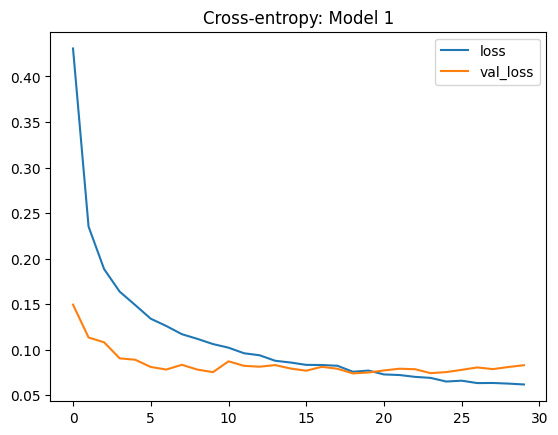

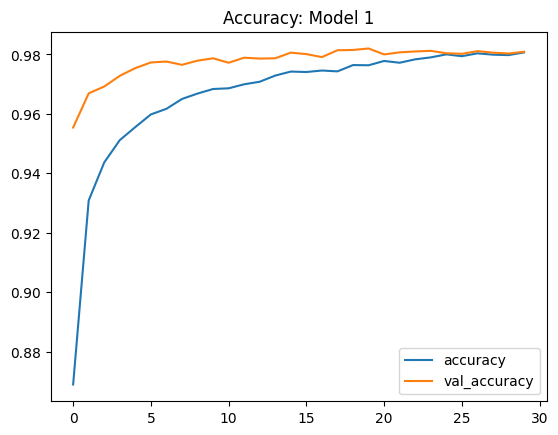

In [7]:
model_NN.compile(
    optimizer = Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy', #used binary_crossentropy in kaggle, but this is not binary classification
    metrics=['accuracy'], #same thing here
)
early_stopping = keras.callbacks.EarlyStopping( #early stopping
    patience=1,
    min_delta=0.001,
    restore_best_weights=True,
)
history = model_NN.fit( #fitting the data
    x_train_NN, y_train,
    validation_data=(x_test_NN, y_test),
    batch_size=32,
    epochs=30,
)

history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot(title="Cross-entropy: Model 1")
history_df.loc[:, ['accuracy', 'val_accuracy']].plot(title="Accuracy: Model 1")

In [8]:
input_shape=(28,28,1,)
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255
x_train_CNN = np.expand_dims(x_train, -1)
x_test_CNN = np.expand_dims(x_test, -1)
y_train_CNN = np.expand_dims(y_train, -1)
y_test_CNN = np.expand_dims(y_test, -1)
print("x_train_CNN:", x_train_CNN.shape)
print(x_train_CNN[0])
print(x_test_CNN[0])

x_train_CNN: (60000, 28, 28, 1)
[[[0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]]

 [[0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]]

 [[0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0

In [9]:
input_shape = (28, 28, 1)

model_CNN = keras.Sequential([
    keras.Input(shape=input_shape), #we're gonna make it (28,28,1)
    layers.Conv2D(32, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 45s 142ms/step - accuracy: 0.7414 - loss: 0.8609 - val_accuracy: 0.9711 - val_loss: 0.1004
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 81s 140ms/step - accuracy: 0.9614 - loss: 0.1301 - val_accuracy: 0.9802 - val_loss: 0.0623
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 82s 139ms/step - accuracy: 0.9709 - loss: 0.0949 - val_accuracy: 0.9849 - val_loss: 0.0496
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 82s 139ms/step - accuracy: 0.9765 - loss: 0.0748 - val_accuracy: 0.9861 - val_loss: 0.0415
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 82s 139ms/step - accuracy: 0.9804 - loss: 0.0628 - val_accuracy: 0.9871 - val_loss: 0.0403
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 84s 147ms/step - accuracy: 0.9830 - loss: 0.0560 - val_accuracy: 0.9877 - val_loss: 0.0351
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 79s 139ms/step - accuracy: 0.9837 - loss: 0.0538 - val_accuracy: 0.9896 - val_loss: 0.0307
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 42s 139ms/step - accuracy: 0.9849 - loss: 0

<Axes: title={'center': 'Accuracy: Model 1'}>

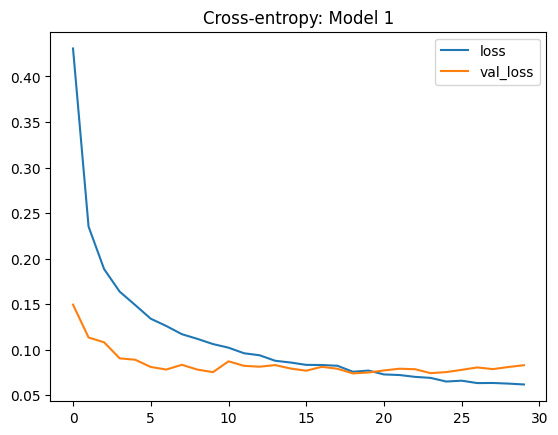

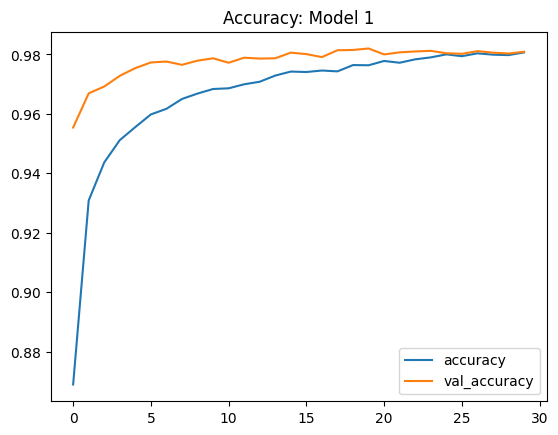

In [10]:
model_CNN.compile(
    optimizer = 'adam',
    loss='sparse_categorical_crossentropy', #used binary_crossentropy in kaggle, but this is not binary classification
    metrics=['accuracy'], #same thing here
)
early_stopping = keras.callbacks.EarlyStopping( #early stopping
    patience=1,
    min_delta=0.001,
    restore_best_weights=True,
)
model_CNN.fit( #fitting the data
    x_train_CNN, y_train,
    validation_data=(x_test_CNN, y_test),
    epochs=10,
    batch_size=200,
    callbacks = [early_stopping]
)

history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot(title="Cross-entropy: Model 1")
history_df.loc[:, ['accuracy', 'val_accuracy']].plot(title="Accuracy: Model 1")

In [11]:
model_NN.save_weights("mnist_nn.weights.h5", overwrite=True)
model_CNN.save_weights("mnist_cnn.weights.h5", overwrite=True)

In [12]:
model_NN.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ batch_normalization                  │ (None, 784)                 │           3,136 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 738,144 (2.82 MB)

 Trainable params: 245,226 (957.91 KB)

 Non-trainable params: 2,464 (9.62 KB)

 Optimizer params: 490,454 (1.87 MB)

In [13]:
model_CNN.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │          16,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 104,480 (408.13 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 69,654 (272.09 KB)



1.   Data Handling
     --> NNs and CNNs differ significantly in how they process input data. NNs treat each pixel as an independent feature by flattening the 28×28 MNIST images into a one-dimensional vector of 784 values.
     
     Conversely, CNNs keep the 28×28×1 format. They use filters to detect features like edges and textures, allowing them to identify patterns. This is more complex and is a better way of capturing such features.
     
     Both models use the categorical cross-entropy loss function for classification tasks on the MNIST dataset.

2.   Parameter Sharing
     --> In NNs, each neuron has it's own unique set of weights. And because there are many neurons (each neuron is connected to a neuron in a previous layer), there is a large number of parameters. CNNs aim to reduce this great amount using parameter sharing in convolution filters that slides over an image and reduces the amount of trainable parameters.

3.   Training time
     --> The CNN took much longer to rain (about 80 seconds per batch) compared to the NN (about 15-20 seconds). This is because of the complexity of CNNs vs NNs. Even though there are less trainable parameters, the usage of multiple filters and pooling layers contribute to the longer training time.

4.   Number of Parameters Trained
     --> As explained in question 2, NNs have more trainable parameters than CNNs. In this project, the NN had 245,226 while the CNN had 34,826.
